# Imports

In [1]:
import ms1isotopes
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

# Dataset from Ahrné et al.

In [7]:
input_mzml_sample1 = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12042_uncalibrated.mzML"
psms_sample1 = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Results\UPS2_data_sample1\psm.tsv"

input_mzml_sample2 = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12043_uncalibrated.mzML"
psms_sample2 = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Results\UPS2_data_sample2\psm.tsv"

In [8]:
psms_sample1_df = pd.read_csv(psms_sample1, sep="\t")
psms_sample2_df = pd.read_csv(psms_sample2, sep="\t")


In [9]:
input_data_sample1 = psms_sample1_df[["Peptide", "Charge", "Assigned Modifications", "Retention", "Observed M/Z"]]
input_data_sample1.columns = ["Peptide_Sequence", "Charge_State", "Modifications", "RetentionTime", "MZ"]
input_data_sample1["RetentionTimeWindowBefore"] = 5
input_data_sample1["RetentionTimeWindowAfter"] = 5
input_data_sample1["ErrorTolerance"] = 5

input_data_sample2 = psms_sample2_df[["Peptide", "Charge", "Assigned Modifications", "Retention", "Observed M/Z"]]
input_data_sample2.columns = ["Peptide_Sequence", "Charge_State", "Modifications", "RetentionTime", "MZ"]
input_data_sample2["RetentionTimeWindowBefore"] = 5
input_data_sample2["RetentionTimeWindowAfter"] = 5
input_data_sample2["ErrorTolerance"] = 5

C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3182637248.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data_sample1["RetentionTimeWindowBefore"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3182637248.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data_sample1["RetentionTimeWindowAfter"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3182637248.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [5]:
results_ups_sample1 = ms1isotopes.extract_ms1_isotope_distributions(
    mzml_path=input_mzml_sample1,
    input_list=input_data_sample1,
)

Loaded 9014 MS1 spectra from C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12042_uncalibrated.mzML
Processing 1849 entries from input list
  Processed 100/1849 entries
  Processed 200/1849 entries
  Processed 300/1849 entries
  Processed 400/1849 entries
  Processed 500/1849 entries
  Processed 600/1849 entries
  Processed 700/1849 entries
  Processed 800/1849 entries
  Processed 900/1849 entries
  Processed 1000/1849 entries
  Processed 1100/1849 entries
  Processed 1300/1849 entries
  Processed 1400/1849 entries
  Processed 1500/1849 entries
  Processed 1600/1849 entries
  Processed 1700/1849 entries
  Processed 1800/1849 entries
Done. Extracted 17367 isotope distributions.


In [10]:
results_ups_sample2 = ms1isotopes.extract_ms1_isotope_distributions(
    mzml_path=input_mzml_sample2,
    input_list=input_data_sample2,
)

Loaded 9130 MS1 spectra from C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12043_uncalibrated.mzML
Processing 1849 entries from input list
  Processed 100/1849 entries
  Processed 200/1849 entries
  Processed 300/1849 entries
  Processed 400/1849 entries
  Processed 500/1849 entries
  Processed 600/1849 entries
  Processed 700/1849 entries
  Processed 800/1849 entries
  Processed 900/1849 entries
  Processed 1000/1849 entries
  Processed 1100/1849 entries
  Processed 1200/1849 entries
  Processed 1300/1849 entries
  Processed 1400/1849 entries
  Processed 1500/1849 entries
  Processed 1600/1849 entries
  Processed 1700/1849 entries
  Processed 1800/1849 entries
Done. Extracted 17587 isotope distributions.


# Dataset from ProteomeTools

In [29]:
input_mzml = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2_uncalibrated.mzML"
psms = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Results\ProteomeTools_data\psm.tsv"

In [30]:
psms_df = pd.read_csv(psms, sep="\t")
psms_df

,Spectrum,Spectrum File,Peptide,Modified Peptide,Extended Peptide,Prev AA,Next AA,Peptide Length,Charge,Retention,...,Is Decoy,Is Contaminant,Is Unique,Protein,Protein ID,Entry Name,Gene,Protein Description,Mapped Genes,Mapped Proteins
0,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.02...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,HEHISSDYAGK,NaN,HEEHHYDK.HEHISSDYAGK.TFAHTESH,K,T,11,2,711.3484,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
1,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.02...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,HEHISSDYAGK,NaN,HEEHHYDK.HEHISSDYAGK.TFAHTESH,K,T,11,2,711.3992,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
2,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.02...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,HEHISSDYAGK,NaN,HEEHHYDK.HEHISSDYAGK.TFAHTESH,K,T,11,3,713.5049,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
3,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.02...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,HEHISSDYAGK,NaN,HEEHHYDK.HEHISSDYAGK.TFAHTESH,K,T,11,3,713.5223,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
4,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.02...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,HEHISSDYAGK,NaN,HEEHHYDK.HEHISSDYAGK.TFAHTESH,K,T,11,2,717.1440,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.47...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,SILDYVSLVEK,NaN,FLDGFSVK.SILDYVSLVEK.KPEPTIDE,K,K,11,2,3222.4473,...,False,False,True,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,NaN,QC_JPT_QC_Peptide,NaN,NaN
534,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.47...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,SILDYVSLVEK,NaN,FLDGFSVK.SILDYVSLVEK.KPEPTIDE,K,K,11,2,3222.4646,...,False,False,True,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,NaN,QC_JPT_QC_Peptide,NaN,NaN
535,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.47...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,FFLTGTSIFVK,NaN,IFFDTFDK.FFLTGTSIFVK.GDFTFFID,K,G,11,2,3226.1500,...,False,False,True,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,QC_JPT_RT_Peptide,NaN,QC_JPT_RT_Peptide,NaN,NaN
536,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2.48...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,YGFSSEDIFTK,NaN,YSDFLSDK.YGFSSEDIFTK.VDTFLDGF,K,V,11,2,3268.9417,...,False,False,True,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,QC_JPT_QC_Peptide,NaN,QC_JPT_QC_Peptide,NaN,NaN


In [13]:
input_data = psms_df[["Peptide", "Charge", "Assigned Modifications", "Retention", "Observed M/Z"]]
input_data.columns = ["Peptide_Sequence", "Charge_State", "Modifications", "RetentionTime", "MZ"]
input_data["RetentionTimeWindowBefore"] = 5
input_data["RetentionTimeWindowAfter"] = 5
input_data["ErrorTolerance"] = 5
input_data

C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data["RetentionTimeWindowBefore"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data["RetentionTimeWindowAfter"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

,Peptide_Sequence,Charge_State,Modifications,RetentionTime,MZ,RetentionTimeWindowBefore,RetentionTimeWindowAfter,ErrorTolerance
0,HEHISSDYAGK,2,NaN,711.3484,622.2896,5,5,5
1,HEHISSDYAGK,2,NaN,711.3992,622.2896,5,5,5
2,HEHISSDYAGK,3,NaN,713.5049,415.1953,5,5,5
3,HEHISSDYAGK,3,NaN,713.5223,415.1953,5,5,5
4,HEHISSDYAGK,2,NaN,717.1440,622.2898,5,5,5
...,...,...,...,...,...,...,...,...
533,SILDYVSLVEK,2,NaN,3222.4473,633.3559,5,5,5
534,SILDYVSLVEK,2,NaN,3222.4646,633.3559,5,5,5
535,FFLTGTSIFVK,2,NaN,3226.1500,630.3546,5,5,5
536,YGFSSEDIFTK,2,NaN,3268.9417,647.8010,5,5,5


In [14]:
results_PT = ms1isotopes.extract_ms1_isotope_distributions(
    mzml_path=input_mzml,
    input_list=input_data,
)

Loaded 3901 MS1 spectra from C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2_uncalibrated.mzML
Processing 538 entries from input list
  Processed 100/538 entries
  Processed 200/538 entries
  Processed 300/538 entries
  Processed 400/538 entries
  Processed 500/538 entries
Done. Extracted 3641 isotope distributions.


# Dataset from timsTOF2

In [15]:
input_mzml = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-36_1_3662.mzML"
psms = r"C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Results\timsTOF_data\psm.tsv"
psms_df = pd.read_csv(psms, sep="\t")
psms_df

,Spectrum,Spectrum File,Peptide,Modified Peptide,Extended Peptide,Prev AA,Next AA,Peptide Length,Charge,Retention,...,Is Decoy,Is Contaminant,Is Unique,Protein,Protein ID,Entry Name,Gene,Protein Description,Mapped Genes,Mapped Proteins
0,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AQESKIRYK,NaN,VQMSVGHK.AQESKIRYK.TNEPVWEE,K,T,9,2,52.8315,...,False,False,True,sp|A0FGR8|ESYT2_HUMAN,A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2,NaN,NaN
1,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AQESKIRYK,NaN,VQMSVGHK.AQESKIRYK.TNEPVWEE,K,T,9,2,57.3718,...,False,False,True,sp|A0FGR8|ESYT2_HUMAN,A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2,NaN,NaN
2,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AQESKIRYK,NaN,VQMSVGHK.AQESKIRYK.TNEPVWEE,K,T,9,2,61.9123,...,False,False,True,sp|A0FGR8|ESYT2_HUMAN,A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2,NaN,NaN
3,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AQESKIRYK,NaN,VQMSVGHK.AQESKIRYK.TNEPVWEE,K,T,9,2,64.1820,...,False,False,True,sp|A0FGR8|ESYT2_HUMAN,A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2,NaN,NaN
4,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AQESKIRYK,NaN,VQMSVGHK.AQESKIRYK.TNEPVWEE,K,T,9,2,66.4526,...,False,False,True,sp|A0FGR8|ESYT2_HUMAN,A0FGR8,ESYT2_HUMAN,ESYT2,Extended synaptotagmin-2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,YISPDQLADLYK,NaN,KSPDDPSR.YISPDQLADLYK.SFIKDYPV,R,S,12,2,3172.5815,...,False,False,True,sp|P06733|ENOA_HUMAN,P06733,ENOA_HUMAN,ENO1,Alpha-enolase,NaN,NaN
924,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,YLVNDLVLR,NaN,PISVTLQR.YLVNDLVLR.DYMIPAKT,R,D,9,2,3174.8525,...,False,False,True,sp|P05108|CP11A_HUMAN,P05108,CP11A_HUMAN,CYP11A1,"Cholesterol side-chain cleavage enzyme, mitoch...",NaN,NaN
925,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,TIGGGDDSFNTFFSETGAGK,NaN,DGQMPSDK.TIGGGDDSFNTFFSETGAGK.HVPRAVFV,K,H,20,2,3211.2024,...,False,False,False,sp|P0DPH7|TBA3C_HUMAN,P0DPH7,TBA3C_HUMAN,TUBA3C,Tubulin alpha-3C chain,"TUBA1A, TUBA1B, TUBA1C, TUBA3D, TUBA3E","sp|P0DPH8|TBA3D_HUMAN, sp|P68363|TBA1B_HUMAN, ..."
926,Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-...,C:\Users\VILENNEF\Documents\tmp_results\MS1\in...,AILVDLEPGTMDSVR,NaN,TGGKYVPR.AILVDLEPGTMDSVR.SGPFGQIF,R,S,15,2,3222.5674,...,False,False,False,sp|P07437|TBB5_HUMAN,P07437,TBB5_HUMAN,TUBB,Tubulin beta chain,"TUBB2A, TUBB2B, TUBB3","sp|Q13509|TBB3_HUMAN, sp|Q13885|TBB2A_HUMAN, s..."


In [16]:
input_data = psms_df[["Peptide", "Charge", "Assigned Modifications", "Retention", "Observed M/Z"]]
input_data.columns = ["Peptide_Sequence", "Charge_State", "Modifications", "RetentionTime", "MZ"]
input_data["RetentionTimeWindowBefore"] = 5
input_data["RetentionTimeWindowAfter"] = 5
input_data["ErrorTolerance"] = 5
input_data

C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data["RetentionTimeWindowBefore"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_data["RetentionTimeWindowAfter"] = 5
C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\3763534946.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

,Peptide_Sequence,Charge_State,Modifications,RetentionTime,MZ,RetentionTimeWindowBefore,RetentionTimeWindowAfter,ErrorTolerance
0,AQESKIRYK,2,NaN,52.8315,561.8156,5,5,5
1,AQESKIRYK,2,NaN,57.3718,561.8190,5,5,5
2,AQESKIRYK,2,NaN,61.9123,561.8209,5,5,5
3,AQESKIRYK,2,NaN,64.1820,561.8177,5,5,5
4,AQESKIRYK,2,NaN,66.4526,561.8171,5,5,5
...,...,...,...,...,...,...,...,...
923,YISPDQLADLYK,2,NaN,3172.5815,713.3643,5,5,5
924,YLVNDLVLR,2,NaN,3174.8525,552.8259,5,5,5
925,TIGGGDDSFNTFFSETGAGK,2,NaN,3211.2024,1004.4432,5,5,5
926,AILVDLEPGTMDSVR,2,NaN,3222.5674,808.4157,5,5,5


In [17]:
results_timsTOF = ms1isotopes.extract_ms1_isotope_distributions(
    mzml_path=input_mzml,
    input_list=input_data,
)

Loaded 1839 MS1 spectra from C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\Neo_sh14_patient1_HLAI_0412_HM1114_tims_Slot1-36_1_3662.mzML
Processing 928 entries from input list
  Processed 100/928 entries
  Processed 200/928 entries
  Processed 300/928 entries
  Processed 400/928 entries
  Processed 500/928 entries
  Processed 600/928 entries
  Processed 700/928 entries
  Processed 800/928 entries
  Processed 900/928 entries
Done. Extracted 4053 isotope distributions.


# Combining results

In [34]:
results_timsTOF.SpectralAngle.median()

np.float64(0.2582059666182792)

In [18]:
results_PT["Dataset"] = "ProteomeTools (Fusion)"
results_ups_sample1["Dataset"] = "UPS2 (Velos)"
results_ups_sample2["Dataset"] = "UPS2 (Velos)"
results_timsTOF["Dataset"] = "timsTOF Pro 2"

results_combined = pd.concat([results_PT, results_ups_sample1, results_ups_sample2, results_timsTOF], ignore_index=True)
results_combined

,RawFile,Spectrum,PeptideSequence,Modifications,PeptideLength,TheoreticalMonoIsotopicMass,TheoreticalAverageMass,ChargeState,TheoreticalMZ,ObservedMZ,...,BRAINRelativeIsotopePeak2Intensity,BRAINRelativeIsotopePeak3Intensity,BRAINRelativeIsotopePeak4Intensity,BRAINRelativeIsotopePeak5Intensity,BRAINRelativeIsotopePeak6Intensity,Distribution,SpectralAngle,NPeaks,ConsecutivePeaks,Dataset
0,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,controllerType=0 controllerNumber=1 scan=2509,HEHISSDYAGK,None,11,1242.562895,1243.2982,2,622.288723,622.2896,...,0.327078,0.124079,0.034624,0.007815,0.001499,False,NaN,1,False,ProteomeTools (Fusion)
1,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,controllerType=0 controllerNumber=1 scan=2518,HEHISSDYAGK,None,11,1242.562895,1243.2982,2,622.288723,622.2896,...,0.327078,0.124079,0.034624,0.007815,0.001499,False,NaN,1,False,ProteomeTools (Fusion)
2,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,controllerType=0 controllerNumber=1 scan=2523,HEHISSDYAGK,None,11,1242.562895,1243.2982,2,622.288723,622.2896,...,0.327078,0.124079,0.034624,0.007815,0.001499,True,0.104327,2,True,ProteomeTools (Fusion)
3,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,controllerType=0 controllerNumber=1 scan=2528,HEHISSDYAGK,None,11,1242.562895,1243.2982,2,622.288723,622.2896,...,0.327078,0.124079,0.034624,0.007815,0.001499,True,0.047239,2,True,ProteomeTools (Fusion)
4,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,controllerType=0 controllerNumber=1 scan=2531,HEHISSDYAGK,None,11,1242.562895,1243.2982,2,622.288723,622.2896,...,0.327078,0.124079,0.034624,0.007815,0.001499,True,0.174120,4,True,ProteomeTools (Fusion)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42643,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,merged=259804 frame=15301 scanStart=1 scanEnd=...,YISPDQLADLYK,None,12,1424.718725,1425.6012,2,713.366638,713.3643,...,0.344310,0.152292,0.048838,0.012549,0.002724,True,1.178810,2,False,timsTOF Pro 2
42644,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,merged=259953 frame=15312 scanStart=1 scanEnd=...,YISPDQLADLYK,None,12,1424.718725,1425.6012,2,713.366638,713.3643,...,0.344310,0.152292,0.048838,0.012549,0.002724,True,1.129206,3,False,timsTOF Pro 2
42645,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,merged=266142 frame=15642 scanStart=1 scanEnd=...,SSASAPDVDDPEAFPALA,None,18,1758.794775,1759.8439,2,880.404663,880.4036,...,0.346178,0.179603,0.067808,0.020573,0.005286,True,0.397718,3,True,timsTOF Pro 2
42646,C:\Users\VILENNEF\OneDrive - VITO\Documents\Ph...,merged=266368 frame=15653 scanStart=1 scanEnd=...,SSASAPDVDDPEAFPALA,None,18,1758.794775,1759.8439,2,880.404663,880.4036,...,0.346178,0.179603,0.067808,0.020573,0.005286,True,0.417474,2,False,timsTOF Pro 2


C:\Users\VILENNEF\AppData\Local\Temp\ipykernel_48420\899338049.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Auto-detected UPS2 replicates: 'C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12042_uncalibrated.mzML' and 'C:\Users\VILENNEF\OneDrive - VITO\Documents\PhD(2022-2026)\Articles\MS1IsotopeDistributionsDatasetWorkflow\Validation\Data\mzml\A11-12043_uncalibrated.mzML'


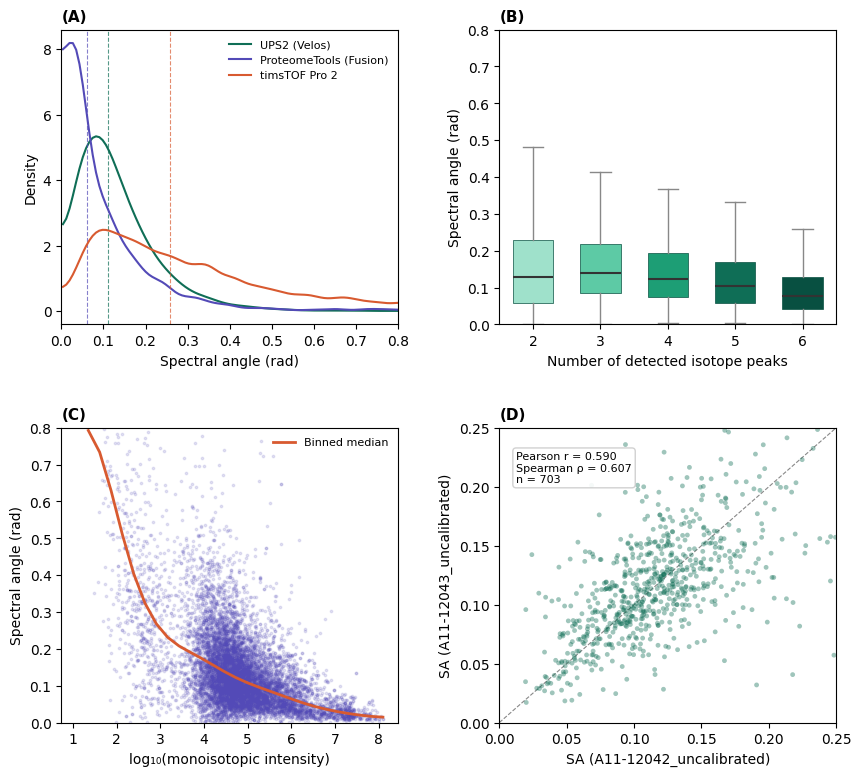

Saved: figure2_validation.png, .pdf, .svg


In [ ]:
"""
Figure 2: Validation of ms1isotopes across instruments and conditions.

Expects a DataFrame `results_combined` with columns:
    - Dataset: str ("UPS2 (Velos)", "ProteomeTools (Fusion)", "timsTOF Pro 2", etc.)
    - SpectralAngle: float
    - NPeaks: int
    - IsotopePeak1Intensity: float (monoisotopic peak intensity)
    - Distribution: bool (True if ≥2 peaks)
    - PeptideSequence, ChargeState, Modifications: for replicate matching
    - RawFile: str (to distinguish UPS2 replicates)

For panel D, the UPS2 data must contain two raw files (replicates).
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# Adjust these to match your Dataset column values
DATASET_LABELS = {
    "UPS2 (Velos)": "#0F6E56",           # teal
    "ProteomeTools (Fusion)": "#534AB7",  # purple
    "timsTOF Pro 2": "#D85A30",           # coral
}

# If your dataset labels differ, change the keys above. E.g.:
# DATASET_LABELS = {
#     "UPS2": "#0F6E56",
#     "ProteomeTools": "#534AB7",
#     "Immunopeptidomics": "#D85A30",
# }

# UPS2 replicate raw file names — adjust to match your RawFile column
UPS2_DATASET_NAME = "UPS2 (Velos)"  # must match a key in DATASET_LABELS
# The two replicate files — adjust these strings:
UPS2_REP1 = None  # Will auto-detect from data if None
UPS2_REP2 = None

FIGSIZE = (10, 9)
DPI = 600

# ---------------------------------------------------------------------------
# Filter to distributions with ≥2 peaks
# ---------------------------------------------------------------------------

df = results_combined[results_combined["Distribution"] == True].copy()
df = df.dropna(subset=["SpectralAngle"])


# ---------------------------------------------------------------------------
# Panel A: SA distributions per dataset
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
fig.subplots_adjust(hspace=0.35, wspace=0.30)

ax = axes[0, 0]

for dataset, color in DATASET_LABELS.items():
    subset = df[df["Dataset"] == dataset]["SpectralAngle"]
    if len(subset) == 0:
        print(f"Warning: no data for dataset '{dataset}', skipping panel A entry")
        continue

    # KDE via histogram + gaussian smoothing (avoids scipy.stats.gaussian_kde edge issues)
    counts, bin_edges = np.histogram(subset, bins=200, range=(0, np.pi / 2), density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    smoothed = gaussian_filter1d(counts, sigma=3)
    ax.plot(bin_centers, smoothed, color=color, linewidth=1.5, label=dataset)
    median_sa = subset.median()
    ax.axvline(median_sa, color=color, linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_xlabel("Spectral angle (rad)")
ax.set_ylabel("Density")
ax.set_xlim(0, 0.8)
ax.legend(fontsize=8, frameon=False)
ax.set_title("(A)", loc="left", fontweight="bold", fontsize=11)


# ---------------------------------------------------------------------------
# Panel B: SA stratified by number of detected peaks
# ---------------------------------------------------------------------------

ax = axes[0, 1]

peak_groups = sorted(df["NPeaks"].unique())
# Filter to 2-6 peaks (1 peak has no SA)
peak_groups = [p for p in peak_groups if 2 <= p <= 6]

box_data = [df[df["NPeaks"] == p]["SpectralAngle"].values for p in peak_groups]

bp = ax.boxplot(
    box_data,
    labels=[str(p) for p in peak_groups],
    patch_artist=True,
    widths=0.6,
    showfliers=False,  # outliers clutter at this scale
    medianprops=dict(color="#333", linewidth=1.5),
    whiskerprops=dict(color="#888"),
    capprops=dict(color="#888"),
)

# Color boxes with a gradient from light to dark teal
teal_shades = ["#9FE1CB", "#5DCAA5", "#1D9E75", "#0F6E56", "#085041"]
for patch, shade in zip(bp["boxes"], teal_shades[:len(peak_groups)]):
    patch.set_facecolor(shade)
    patch.set_edgecolor("#085041")
    patch.set_linewidth(0.5)

ax.set_xlabel("Number of detected isotope peaks")
ax.set_ylabel("Spectral angle (rad)")
ax.set_ylim(0, 0.8)
ax.set_title("(B)", loc="left", fontweight="bold", fontsize=11)


# ---------------------------------------------------------------------------
# Panel C: SA vs log10(monoisotopic intensity)
# ---------------------------------------------------------------------------

ax = axes[1, 0]

# Use monoisotopic peak intensity
intensity_col = "IsotopePeak1Intensity"
df_c = df.dropna(subset=[intensity_col]).copy()
df_c = df_c[df_c[intensity_col] > 0]
df_c["log10_intensity"] = np.log10(df_c[intensity_col])

# Subsample for scatter (too many points otherwise)
n_scatter = min(10_000, len(df_c))
df_scatter = df_c.sample(n=n_scatter, random_state=42)

ax.scatter(
    df_scatter["log10_intensity"],
    df_scatter["SpectralAngle"],
    s=3, alpha=0.15, color="#534AB7", rasterized=True,
)

# Loess-like smoother via binned medians
bins = np.linspace(df_c["log10_intensity"].min(), df_c["log10_intensity"].max(), 30)
bin_centers_c = (bins[:-1] + bins[1:]) / 2
bin_medians = []
for i in range(len(bins) - 1):
    mask = (df_c["log10_intensity"] >= bins[i]) & (df_c["log10_intensity"] < bins[i + 1])
    vals = df_c.loc[mask, "SpectralAngle"]
    bin_medians.append(vals.median() if len(vals) > 10 else np.nan)

bin_medians = np.array(bin_medians)
valid = ~np.isnan(bin_medians)
ax.plot(
    bin_centers_c[valid],
    gaussian_filter1d(bin_medians[valid], sigma=1.5),
    color="#D85A30", linewidth=2, label="Binned median",
)

ax.set_xlabel("log₁₀(monoisotopic intensity)")
ax.set_ylabel("Spectral angle (rad)")
ax.set_ylim(0, 0.8)
ax.legend(fontsize=8, frameon=False)
ax.set_title("(C)", loc="left", fontweight="bold", fontsize=11)


# ---------------------------------------------------------------------------
# Panel D: Replicate concordance (UPS2 only)
# ---------------------------------------------------------------------------

ax = axes[1, 1]

# Get UPS2 data
df_ups2 = df[df["Dataset"] == UPS2_DATASET_NAME].copy()

if len(df_ups2) == 0:
    ax.text(0.5, 0.5, f"No data for\n'{UPS2_DATASET_NAME}'",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#888")
    ax.set_title("(D)", loc="left", fontweight="bold", fontsize=11)
else:
    # Identify the two replicate files
    raw_files = df_ups2["RawFile"].unique()

    if UPS2_REP1 is not None and UPS2_REP2 is not None:
        rep1_name, rep2_name = UPS2_REP1, UPS2_REP2
    elif len(raw_files) >= 2:
        rep1_name, rep2_name = sorted(raw_files)[:2]
        print(f"Auto-detected UPS2 replicates: '{rep1_name}' and '{rep2_name}'")
    else:
        ax.text(0.5, 0.5, "Need 2 replicate\nraw files for UPS2",
                transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#888")
        rep1_name, rep2_name = None, None

    if rep1_name is not None:
        # For each peptide+charge+mod, compute the SA of summed intensities per replicate
        # Group key
        group_cols = ["PeptideSequence", "ChargeState", "Modifications"]

        # Aggregate: sum isotope intensities per peptide per replicate, then recompute SA
        # Simpler approach: take median SA per peptide per replicate
        rep1 = (df_ups2[df_ups2["RawFile"] == rep1_name]
                .groupby(group_cols)["SpectralAngle"].median()
                .rename("SA_rep1"))
        rep2 = (df_ups2[df_ups2["RawFile"] == rep2_name]
                .groupby(group_cols)["SpectralAngle"].median()
                .rename("SA_rep2"))

        merged = pd.merge(rep1, rep2, left_index=True, right_index=True)

        # Zoom to 0-0.2 range (where the linear relationship is strongest)
        zoom = merged[(merged["SA_rep1"] < 0.25) & (merged["SA_rep2"] < 0.25)]

        ax.scatter(
            zoom["SA_rep1"], zoom["SA_rep2"],
            s=12, alpha=0.4, color="#0F6E56", edgecolors="none", rasterized=True,
        )

        # Diagonal reference
        lim = max(zoom["SA_rep1"].max(), zoom["SA_rep2"].max()) * 1.05
        ax.plot([0, lim], [0, lim], color="#888", linewidth=0.8, linestyle="--", zorder=0)

        # Correlation
        if len(zoom) > 5:
            r_pearson, _ = pearsonr(zoom["SA_rep1"], zoom["SA_rep2"])
            r_spearman, _ = spearmanr(zoom["SA_rep1"], zoom["SA_rep2"])
            ax.text(
                0.05, 0.92,
                f"Pearson r = {r_pearson:.3f}\nSpearman ρ = {r_spearman:.3f}\nn = {len(zoom)}",
                transform=ax.transAxes, fontsize=8, verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc", alpha=0.9),
            )

        # Clean labels using raw file basenames
        rep1_short = rep1_name.split("/")[-1].split("\\")[-1].replace(".mzML", "")
        rep2_short = rep2_name.split("/")[-1].split("\\")[-1].replace(".mzML", "")
        ax.set_xlabel(f"SA ({rep1_short})")
        ax.set_ylabel(f"SA ({rep2_short})")
        ax.set_xlim(0, 0.25)
        ax.set_ylim(0, 0.25)

    ax.set_title("(D)", loc="left", fontweight="bold", fontsize=11)


# ---------------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------------

plt.savefig("figure2_validation.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.savefig("figure2_validation.tiff", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.savefig("figure2_validation.svg", bbox_inches="tight", facecolor="white")
plt.show()

print("Saved: figure2_validation.png, .tiff, .svg")